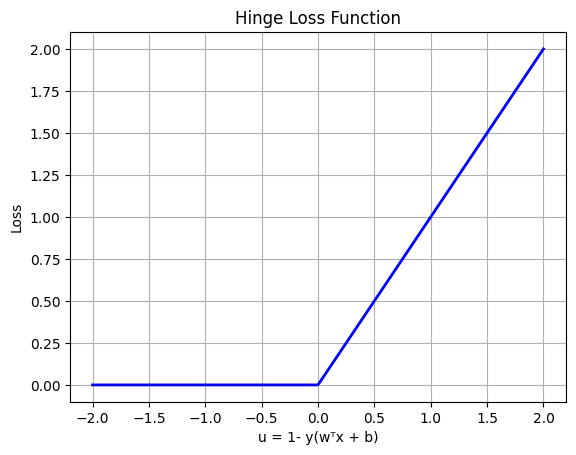

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-2, 2, 400)
hinge = np.maximum(0, u)

plt.figure()
plt.plot(u, hinge, label='Hinge Loss', color='blue', linewidth=2)
plt.title("Hinge Loss Function")
plt.xlabel("u = 1- y(wᵀx + b)")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig("hinge_loss_plot.png", dpi=300)
plt.show()


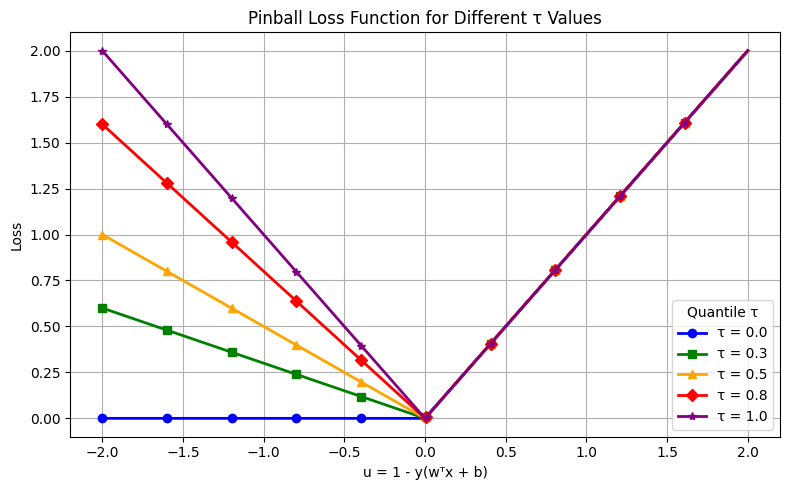

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define range for u
u = np.linspace(-2, 2, 400)

# Different tau values to compare
taus = [0.0, 0.3, 0.5, 0.8, 1.0]
colors = ['blue', 'green', 'orange', 'red', 'purple']
markers = ['o', 's', '^', 'D', '*']

plt.figure(figsize=(8, 5))

for tau, color, marker in zip(taus, colors, markers):
    pinball = np.where(u >= 0, u, -tau * u)
    plt.plot(u, pinball, label=f'τ = {tau}', color=color, linewidth=2, marker=marker, markevery=40)

plt.title("Pinball Loss Function for Different τ Values")
plt.xlabel("u = 1 - y(wᵀx + b)")
plt.ylabel("Loss")
plt.grid(True)
plt.legend(title="Quantile τ")
plt.tight_layout()
plt.savefig("pinball_loss_multiple_tau.png", dpi=300)
plt.show()


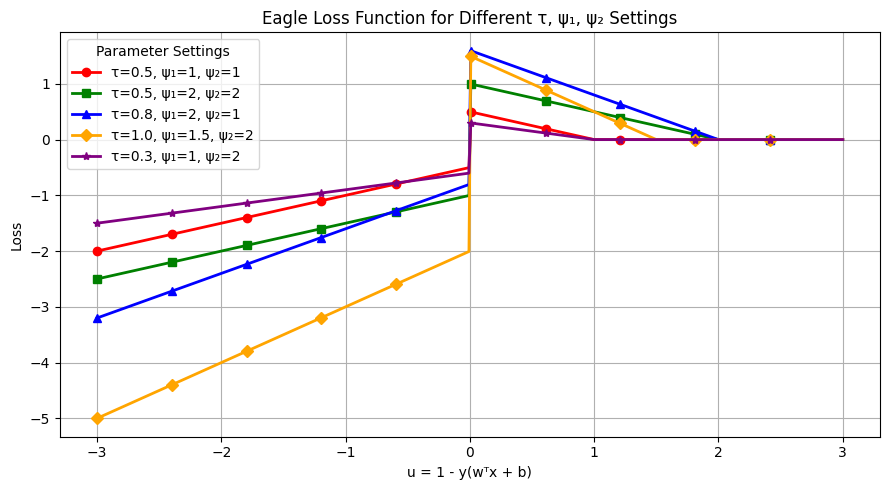

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-3, 3, 400)

configs = [
    (0.5, 1, 1),
    (0.5, 2, 2),
    (0.8, 2, 1),
    (1.0, 1.5, 2),
    (0.3, 1, 2)
]

colors = ['red', 'green', 'blue', 'orange', 'purple']
markers = ['o', 's', '^', 'D', '*']

plt.figure(figsize=(9, 5))

for (tau, psi1, psi2), color, marker in zip(configs, colors, markers):
    eagle = np.piecewise(
        u,
        [u >= psi1, (u >= 0) & (u < psi1), u < 0],
        [0, lambda u: tau * (psi1 - u), lambda u: tau * (-psi2 + u)]
    )
    label = f"τ={tau}, ψ₁={psi1}, ψ₂={psi2}"
    plt.plot(u, eagle, label=label, color=color, linewidth=2, marker=marker, markevery=40)

plt.title("Eagle Loss Function for Different τ, ψ₁, ψ₂ Settings")
plt.xlabel("u = 1 - y(wᵀx + b)")
plt.ylabel("Loss")
plt.grid(True)
plt.legend(title="Parameter Settings", loc="upper left")
plt.tight_layout()
plt.savefig("eagle_loss_multiple_params.png", dpi=300)
plt.show()
